# Sankung Fatty

In the HW files folder is a file called classify_me.csv. The column 'Target' gives the class labels.

1. Read in this file. How many classes are there? How many features are there? Are there any missing entries? 

2. Split into training and test sets (30% test set). Use random_state=5 so your splits are reproducible. 

3. Use all the features to build a classifier on the training set. Try bagging, random forest, boosting, and k-nearest neighbors. For knn, cross validate the number of neighbors you use. In your random forest implementation, build the trees deep -- that is, do not set a value for max_depth. For bagging and random forest,  cross validate the number of trees you use (given by the n_estimators parameter). For your boosting model, validate all of the parameters: n_estimators, learning_rate, and max_depth. In all three models, set random_state=5 so the results are reproducible.  

4. Comment on which model gives the best results on the test set.  For the best model, comment on feature importances (if relevant). 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn import datasets
from sklearn.metrics import accuracy_score

In [3]:
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier

In [4]:
df = pd.read_csv('classify_me.csv')
del df['Unnamed: 0']
df

,A,B,C,D,E,F,G,H,I,J,Target
0,0.150333,-1.468600,0.420842,-0.878333,-1.348358,0.686323,-0.663374,-2.301067,1.302455,0.320666,2
1,-1.632086,-0.705800,0.336495,0.024062,-0.493619,-1.534829,-0.024577,-0.296786,0.320047,0.506105,1
2,-1.285627,1.381077,-0.385668,1.446167,-0.348163,-2.255813,0.272703,-0.964729,-1.515589,0.454248,2
3,-0.012135,-0.729971,-1.132579,1.076787,1.235348,1.234472,-1.809369,0.735971,-1.349093,-0.061655,0
4,-1.303877,0.930213,0.801927,-1.750493,0.846840,-0.258996,-0.507816,0.560169,0.583438,-0.472208,0
...,...,...,...,...,...,...,...,...,...,...,...
995,0.116215,0.066620,1.434035,-0.829447,-1.025267,-1.372505,0.787712,0.239583,1.422715,-0.249433,0
996,0.495383,0.594304,-0.832994,0.846822,0.805704,0.582507,-0.476694,-0.181765,-1.017099,0.123959,1
997,0.247019,-0.527071,-1.397361,-0.945972,0.486671,-0.925210,-0.271900,-0.933125,-1.705268,-0.450054,0
998,1.620174,1.143916,0.242528,-0.937797,-0.390179,0.217223,-0.751655,-0.148348,0.042117,0.248499,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       1000 non-null   float64
 1   B       1000 non-null   float64
 2   C       1000 non-null   float64
 3   D       1000 non-null   float64
 4   E       1000 non-null   float64
 5   F       1000 non-null   float64
 6   G       1000 non-null   float64
 7   H       1000 non-null   float64
 8   I       1000 non-null   float64
 9   J       1000 non-null   float64
 10  Target  1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 86.1 KB


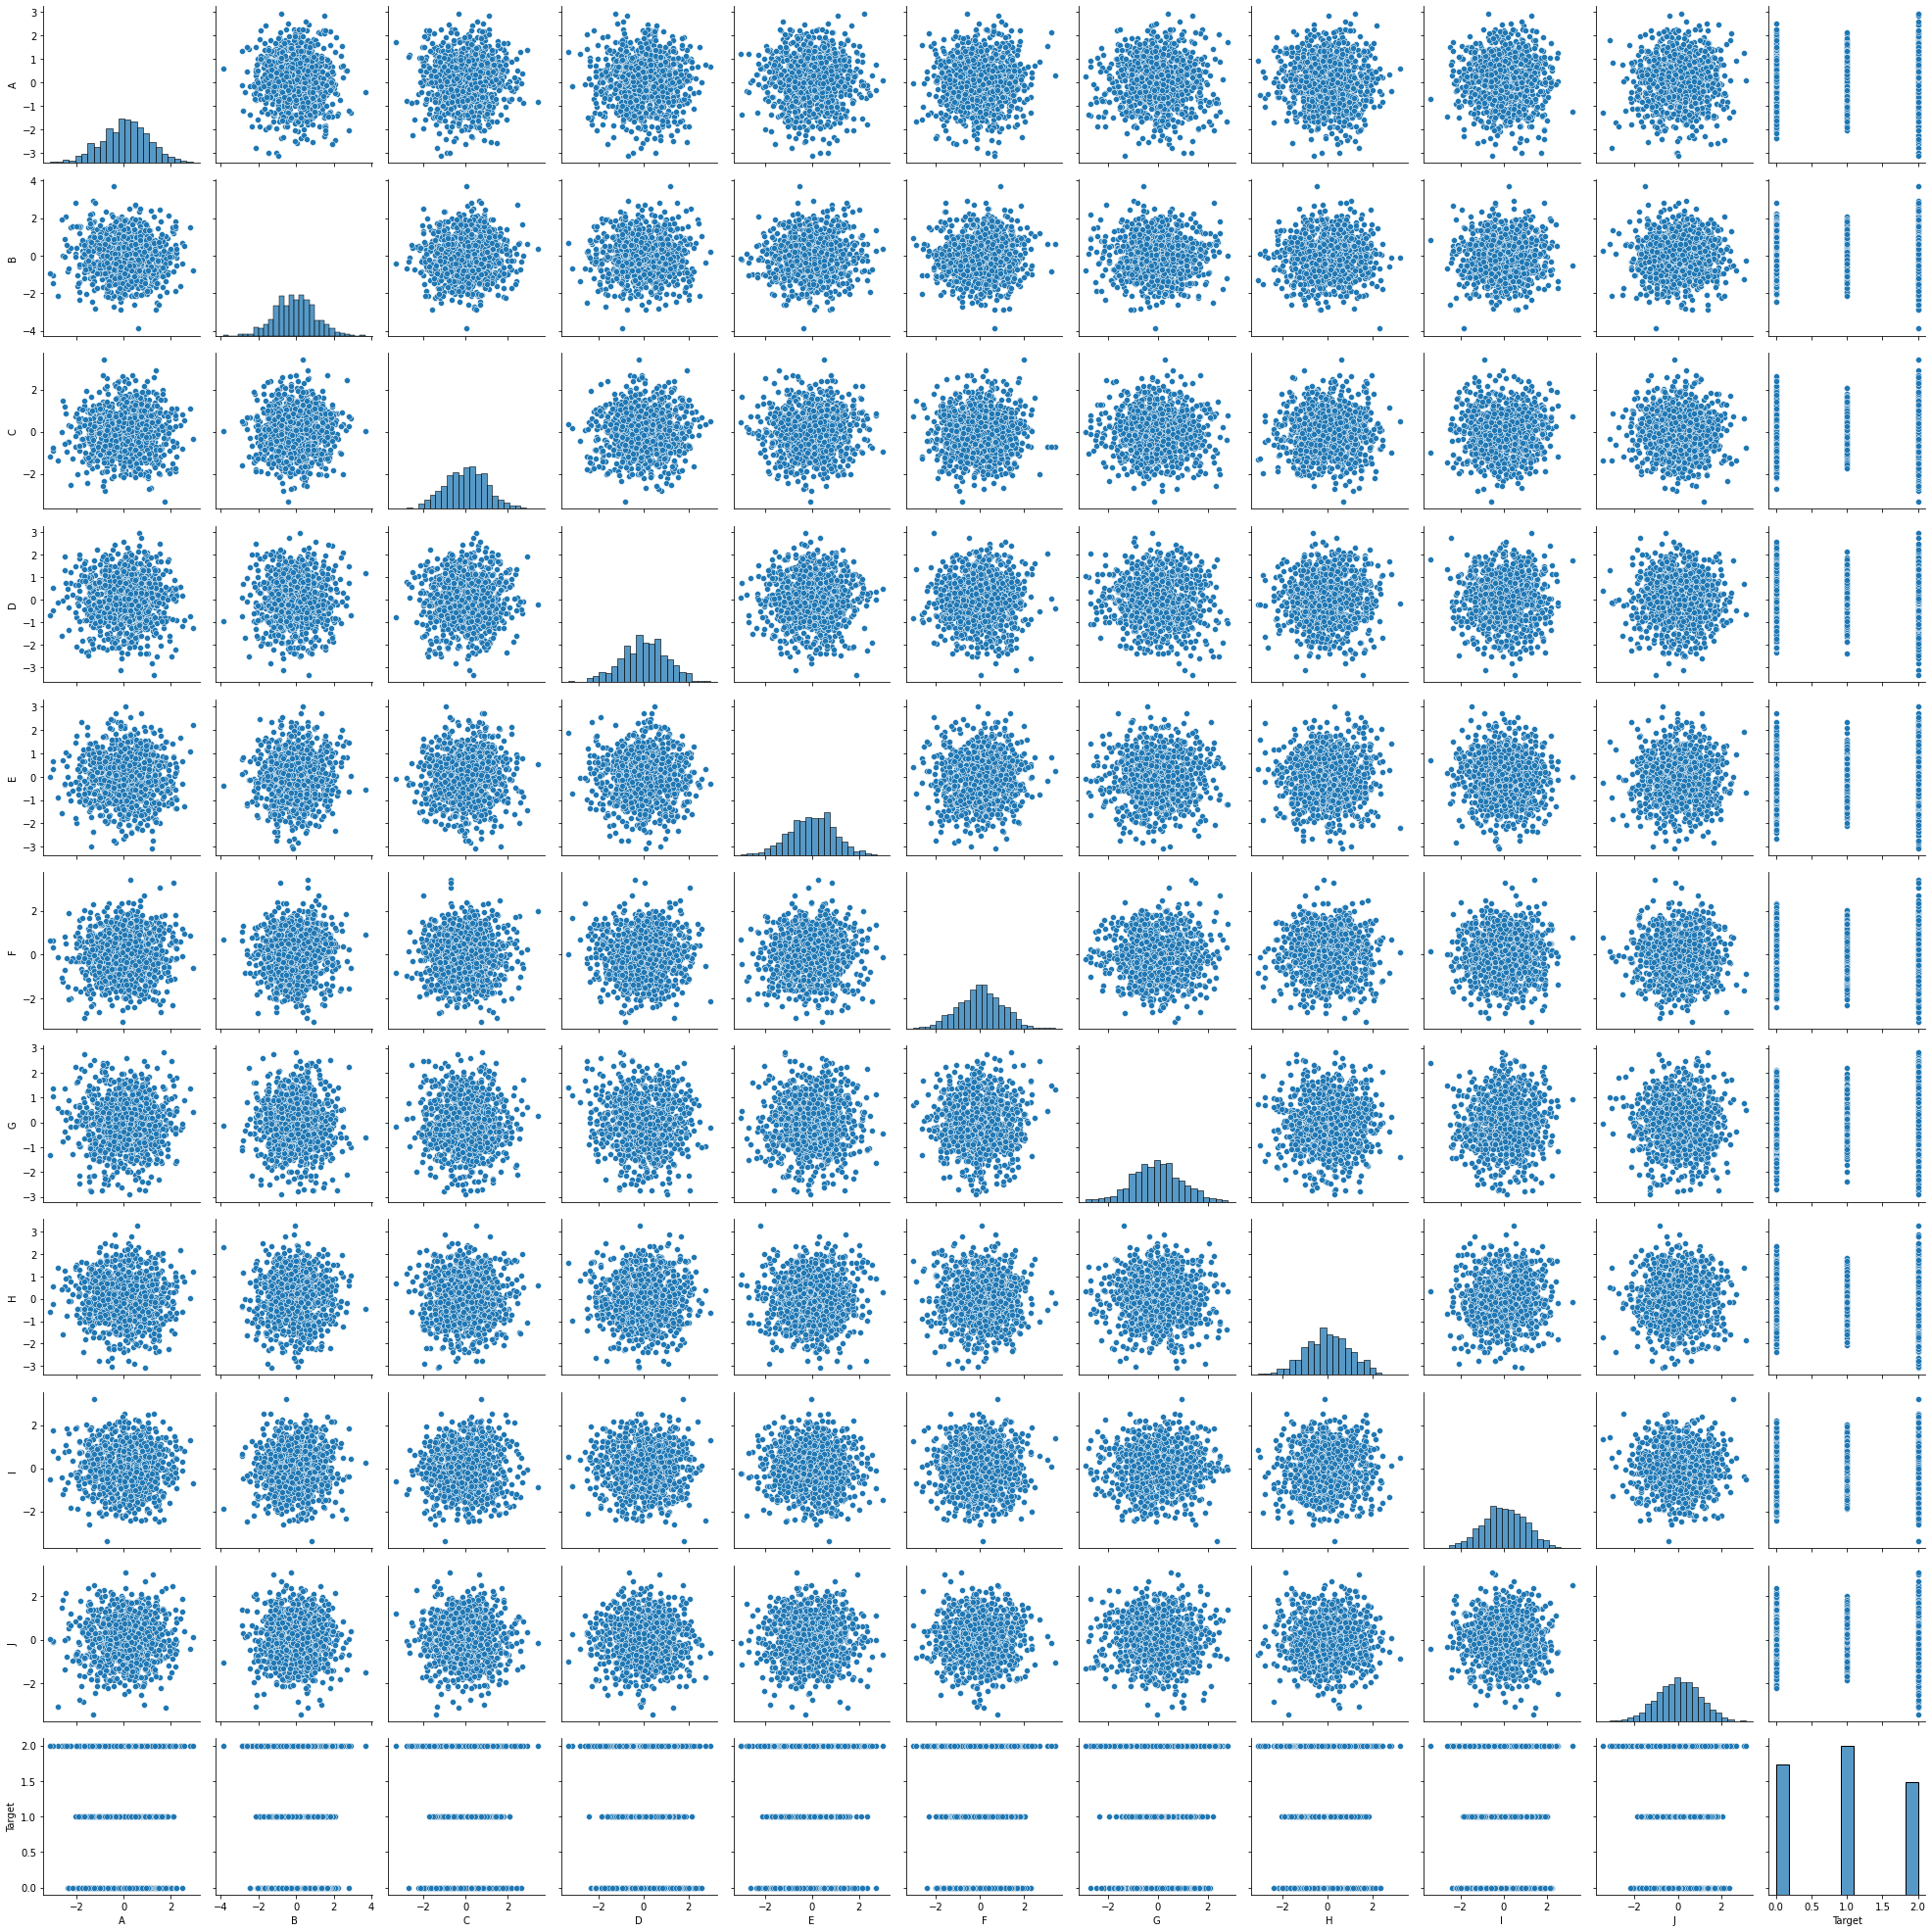

In [6]:
# plot the features
sns.pairplot(df)
plt.tight_layout()

In [6]:
# To check for the check num features and classes
num_classes = df['Target'].nunique()
num_features = df.shape[1] - 1 # exclude the target variable column

print(f"Number of classes: {num_classes}")
print(f"Number of features: {num_features}")


Number of classes: 3
Number of features: 10


In [7]:
df.isnull().sum()

A         0
B         0
C         0
D         0
E         0
F         0
G         0
H         0
I         0
J         0
Target    0
dtype: int64

In [8]:
# There is no missing values in this dataset

In [9]:
# split the data
X = df.drop('Target',axis=1)
y = df['Target']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=5)

# Bagging

In [80]:
# Define the decision tree classifier
dt = DecisionTreeClassifier()

# Define the bagging classifier
bag = BaggingClassifier(dt)

# Define the parameter grid to search over
param_grid = {'n_estimators': [10, 50, 100, 200, 500]}

# Perform grid search with cross-validation
grid_search = GridSearchCV(bag, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Print the best parameter value
print("Best n_estimators value: ", grid_search.best_params_['n_estimators'])



Best n_estimators value:  500


In [81]:
# Evaluate the model on the test set using the best parameter value
bag_best = BaggingClassifier(dt, n_estimators=grid_search.best_params_['n_estimators'],random_state=5)
bag_best.fit(X_train, y_train)
accuracy = bag_best.score(X_test, y_test)
print("Test set accuracy: ", accuracy)


Test set accuracy:  0.63


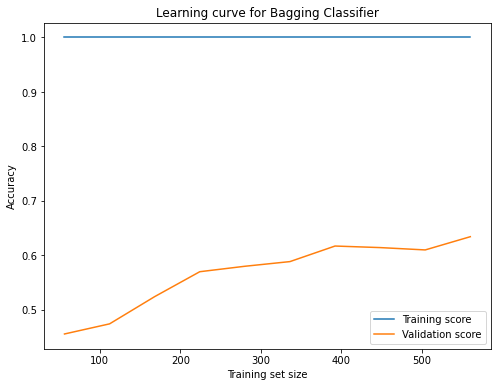

In [90]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    bag_best, X_train, y_train, cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10), shuffle=True, random_state=5)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation score')
plt.title('Learning curve for Bagging Classifier')
plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# Random Forest

In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split


In [74]:

# Define the random forest classifier
rf = RandomForestClassifier()

# Define the parameter grid to search over
param_grid = {'n_estimators': [10, 50, 100, 200, 500]}

# Perform grid search with cross-validation
grid_search = GridSearchCV(rf, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Print the best parameter value
print("Best n_estimators value: ", grid_search.best_params_['n_estimators'])



Best n_estimators value:  500


In [76]:
# woo pretty looks large
# lets use the Best n_estimators for the RandomForest

In [77]:
# Evaluate the model on the test set using the best parameter value
rf_best = RandomForestClassifier(n_estimators=grid_search.best_params_['n_estimators'], random_state=5)
rf_best.fit(X_train, y_train)
accuracy = rf_best.score(X_test, y_test)
print("Test set accuracy: ", accuracy)


Test set accuracy:  0.64


(-1.0, 10.0)

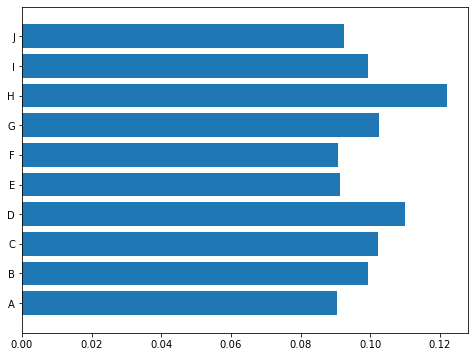

In [83]:
# obtain the feature importances and plot them
plt.figure(figsize=(8,6))
nfeat=X.shape[1]
plt.barh(np.arange(nfeat),rf_best.feature_importances_,align='center')
plt.yticks(np.arange(nfeat),list(X.columns))
plt.ylim(-1,nfeat)

# KNN

In [58]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score

In [65]:

# defining a range of values for 'k'
k_range = range(1, 31)

# create an empty list to store the cross-validation scores
k_scores = []

# perform 10-fold cross-validation for each value of 'k'
for k in k_range:
    knn_clf = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_clf, X_train, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

# find the optimal value of 'k' that gives the highest cross-validation score
optimal_k = k_range[k_scores.index(max(k_scores))]
print(f"Optimal number of neighbors: {optimal_k}")



Optimal number of neighbors: 2


In [79]:
# create a KNN Classifier with the optimal number of neighbors and fit on the training set
knn_clf = KNeighborsClassifier(n_neighbors=optimal_k)
knn_clf.fit(X_train, y_train)

# make predictions on the test set and calculate accuracy
knn_pred = knn_clf.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)
print(f"KNN Classifier accuracy: {knn_acc}")


KNN Classifier accuracy: 0.47


# BOOSTING

In [12]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, train_test_split


In [13]:
# Warning takes solid munites

In [15]:

# define a range of values for each parameter
param_grid = {'n_estimators': [50, 100, 150],
              'learning_rate': [0.01, 0.1, 1],
              'max_depth': [3, 5, 7]}

# create a Gradient Boosting Classifier with random_state=5
gb_clf = GradientBoostingClassifier(random_state=5)

# perform a grid search with 5-fold cross-validation to find the optimal combination of parameters
grid_search = GridSearchCV(gb_clf, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# print the optimal parameters and the corresponding cross-validation score
print(f"Optimal parameters: {grid_search.best_params_}")
print(f"Cross-validation score: {grid_search.best_score_}")



Optimal parameters: {'learning_rate': 1, 'max_depth': 3, 'n_estimators': 150}
Cross-validation score: 0.7357142857142857


In [71]:
# create a Gradient Boosting Classifier with the optimal parameters and fit on the training set
gb_clf = GradientBoostingClassifier(n_estimators=grid_search.best_params_['n_estimators'],
                                     learning_rate=grid_search.best_params_['learning_rate'],
                                     max_depth=grid_search.best_params_['max_depth'],
                                     random_state=5)
gb_clf.fit(X_train, y_train)

# make predictions on the test set and calculate accuracy
gb_pred = gb_clf.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred)
print(f"Gradient Boosting Classifier accuracy: {gb_acc}")


Gradient Boosting Classifier accuracy: 0.7333333333333333


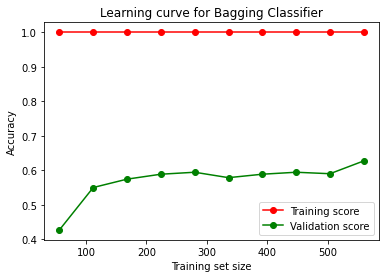

In [91]:
from sklearn.model_selection import learning_curve

# plot the learning curve
train_sizes, train_scores, test_scores = learning_curve(
    bag_best, X_train, y_train, cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training score')
plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Validation score')
plt.legend(loc='best')
plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.title('Learning curve for Bagging Classifier')
plt.show()

The boosting model achieved the highest accuracy of 73%, and it seems that increasing the number of estimators beyond 15 does not improve the model's performance. In fact, increasing the number of estimators may lead to overfitting the data. Therefore, 15 appears to be the optimal number of estimators for this model.

RandomForest and Bagging have a lower accuracy compared to Boosting. This is likely due to the fact that they try to make the model more complex by aggregating multiple decision trees, which can lead to overfitting the data. On the other hand, Boosting works by iteratively improving the performance of a weak learner by adding more weight to misclassified samples, which leads to a better generalization of the model. Therefore, in this case, Boosting is the best model with an accuracy of 73%.